# Notebook 03 _ Analyse Exploratoire des Données (EDA)

## Objectif

Ce notebook a pour objectif d'explorer en profondeur les relations entre les variables climatiques et les indicateurs de production énergétique.

L'analyse exploratoire permettra :

- d'identifier les tendances temporelles ;
- d'étudier les variations saisonnières ;
- d'analyser les relations entre les variables météorologiques et énergétiques ;
- de préparer les futures étapes de création de variables et de modélisation.

Les analyses présentées dans ce notebook serviront à mieux comprendre les facteurs influençant la production énergétique avant l'application des modèles d'intelligence artificielle.

In [1]:
# 1. IMPORTATION DES BIBLIOTHÈQUES

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")

print("Bibliothèques importées.")

Bibliothèques importées.


In [2]:
# 2. DÉFINITION DES CHEMINS

PROJECT_DIR = Path.cwd().parent

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "figures"

INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ENERGY_FILE = PROCESSED_DATA_DIR / "energy_preprocessed.csv"

print("Projet :", PROJECT_DIR)
print("Fichier prétraité :", ENERGY_FILE)
print("Le fichier existe :", ENERGY_FILE.exists())

Projet : c:\Users\celes\Desktop\PFE
Fichier prétraité : c:\Users\celes\Desktop\PFE\data\processed\energy_preprocessed.csv
Le fichier existe : True


In [3]:
# 3. Chargement du dataset prétraité

energy_df = pd.read_csv(
    ENERGY_FILE,
    parse_dates=["Time"]
)

energy_df.head()

,Time,Season,Day_of_the_week,DHI,DNI,GHI,Wind_speed,Humidity,Temperature,PV_production,Wind_production,Electric_demand,Year,Month,Day,Hour,Minute,Weekday,Quarter,Is_weekend
0,2019-01-01 00:00:00,1,1,0.000,0.000,0.000,2.880,56.036,1.820,0,2810,22216,2019,1,1,0,0,1,1,0
1,2019-01-01 00:05:00,1,1,0.000,0.000,0.000,2.880,56.036,1.820,0,2862,22106,2019,1,1,0,5,1,1,0
2,2019-01-01 00:10:00,1,1,0.000,0.000,0.000,2.880,56.194,1.780,0,2916,22130,2019,1,1,0,10,1,1,0
3,2019-01-01 00:15:00,1,1,0.000,0.000,0.000,2.880,56.344,1.740,0,2920,22040,2019,1,1,0,15,1,1,0
4,2019-01-01 00:20:00,1,1,0.000,0.000,0.000,2.840,56.440,1.720,0,2902,21963,2019,1,1,0,20,1,1,0


In [4]:
# 4. INFORMATIONS GÉNÉRALES

print("Dimensions :", energy_df.shape)

print("\nTypes de données :")
display(energy_df.dtypes)

print("\nValeurs manquantes :")
display(energy_df.isnull().sum())

Dimensions : (315648, 20)

Types de données :


Time               datetime64[us]
Season                      int64
Day_of_the_week             int64
DHI                       float64
DNI                       float64
GHI                       float64
Wind_speed                float64
Humidity                  float64
Temperature               float64
PV_production               int64
Wind_production             int64
Electric_demand             int64
Year                        int64
Month                       int64
Day                         int64
Hour                        int64
Minute                      int64
Weekday                     int64
Quarter                     int64
Is_weekend                  int64
dtype: object


Valeurs manquantes :


Time               0
Season             0
Day_of_the_week    0
DHI                0
DNI                0
GHI                0
Wind_speed         0
Humidity           0
Temperature        0
PV_production      0
Wind_production    0
Electric_demand    0
Year               0
Month              0
Day                0
Hour               0
Minute             0
Weekday            0
Quarter            0
Is_weekend         0
dtype: int64

In [5]:
# 5. STATISTIQUES DESCRIPTIVES

display(energy_df.describe().T)

,count,mean,min,25%,50%,75%,max,std
Time,315648,2020-07-01 23:57:30,2019-01-01 00:00:00,2019-10-01 23:58:45,2020-07-01 23:57:30,2021-04-01 23:56:15,2021-12-31 23:55:00,NaN
Season,315648.000,2.508,1.000,2.000,3.000,4.000,4.000,1.117
Day_of_the_week,315648.000,2.998,0.000,1.000,3.000,5.000,6.000,1.998
DHI,315648.000,53.780,0.000,0.000,7.600,98.800,431.000,68.830
DNI,315648.000,288.059,0.000,0.000,38.000,601.600,999.800,336.057
GHI,315648.000,221.788,0.000,0.000,10.200,427.200,1058.200,296.633
Wind_speed,315648.000,2.546,0.660,1.760,2.340,3.160,8.540,1.043
Humidity,315648.000,51.261,11.572,38.380,51.662,63.644,88.688,16.320
Temperature,315648.000,17.472,-0.540,11.200,16.700,22.800,39.020,7.702
PV_production,315648.000,3555.140,-145.000,-34.000,110.000,7952.000,13191.000,4371.602


In [6]:
# 6. PÉRIODE D'ÉTUDE

print("Début :", energy_df["Time"].min())
print("Fin   :", energy_df["Time"].max())

print(
    "\nNombre total de jours :",
    (energy_df["Time"].max() - energy_df["Time"].min()).days
)

Début : 2019-01-01 00:00:00
Fin   : 2021-12-31 23:55:00

Nombre total de jours : 1095


# 7. Analyse temporelle des variables climatiques et énergétiques

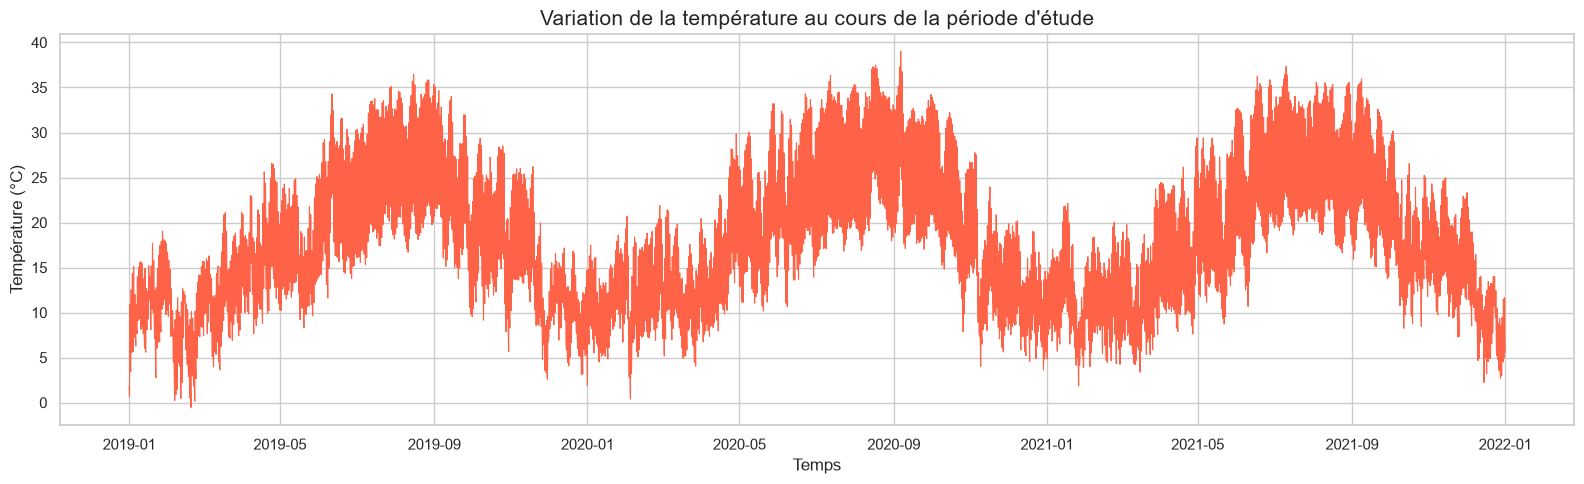

In [7]:
# ÉVOLUTION DE LA TEMPÉRATURE

plt.figure(figsize=(16,5))

plt.plot(
    energy_df["Time"],
    energy_df["Temperature"],
    color="tomato",
    linewidth=0.8
)

plt.title("Variation de la température au cours de la période d'étude", fontsize=15)
plt.xlabel("Temps")
plt.ylabel("Température (°C)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "temperature_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

La température présente une forte saisonnalité annuelle.

Les températures les plus élevées sont observées durant la période estivale, tandis que les températures minimales correspondent aux mois d'hiver.

Cette évolution est cohérente avec les variations climatiques saisonnières et influence directement le potentiel de production photovoltaïque.

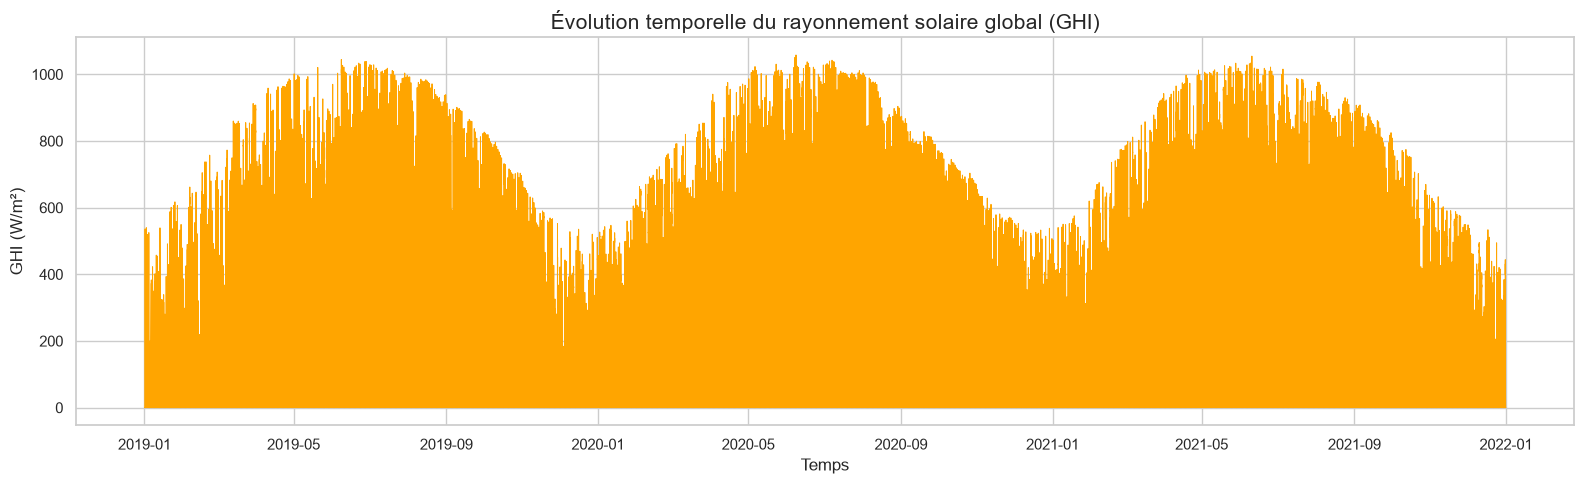

In [8]:
# ÉVOLUTION DU GHI

plt.figure(figsize=(16,5))

plt.plot(
    energy_df["Time"],
    energy_df["GHI"],
    color="orange",
    linewidth=0.7
)

plt.title("Évolution temporelle du rayonnement solaire global (GHI)", fontsize=15)
plt.xlabel("Temps")
plt.ylabel("GHI (W/m²)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ghi_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

Le rayonnement solaire varie fortement selon les saisons.

Les valeurs sont très faibles pendant l'hiver et atteignent leurs maxima durant les mois d'été.

Ces observations expliquent en grande partie les variations de la production photovoltaïque.

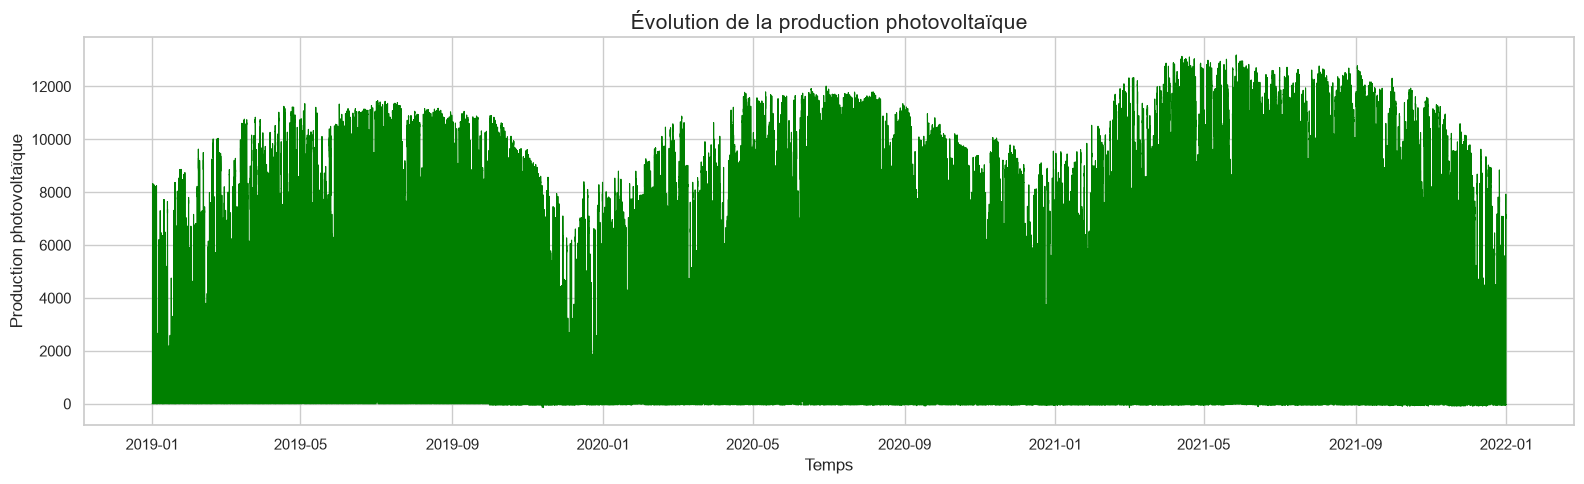

In [9]:
# PRODUCTION PHOTOVOLTAÏQUE

plt.figure(figsize=(16,5))

plt.plot(
    energy_df["Time"],
    energy_df["PV_production"],
    color="green",
    linewidth=0.8
)

plt.title("Évolution de la production photovoltaïque", fontsize=15)
plt.xlabel("Temps")
plt.ylabel("Production photovoltaïque")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pv_production_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

La production photovoltaïque suit une évolution similaire au rayonnement solaire.

Les pics de production correspondent aux périodes de fort ensoleillement, confirmant l'influence majeure des variables climatiques sur la production d'énergie solaire.

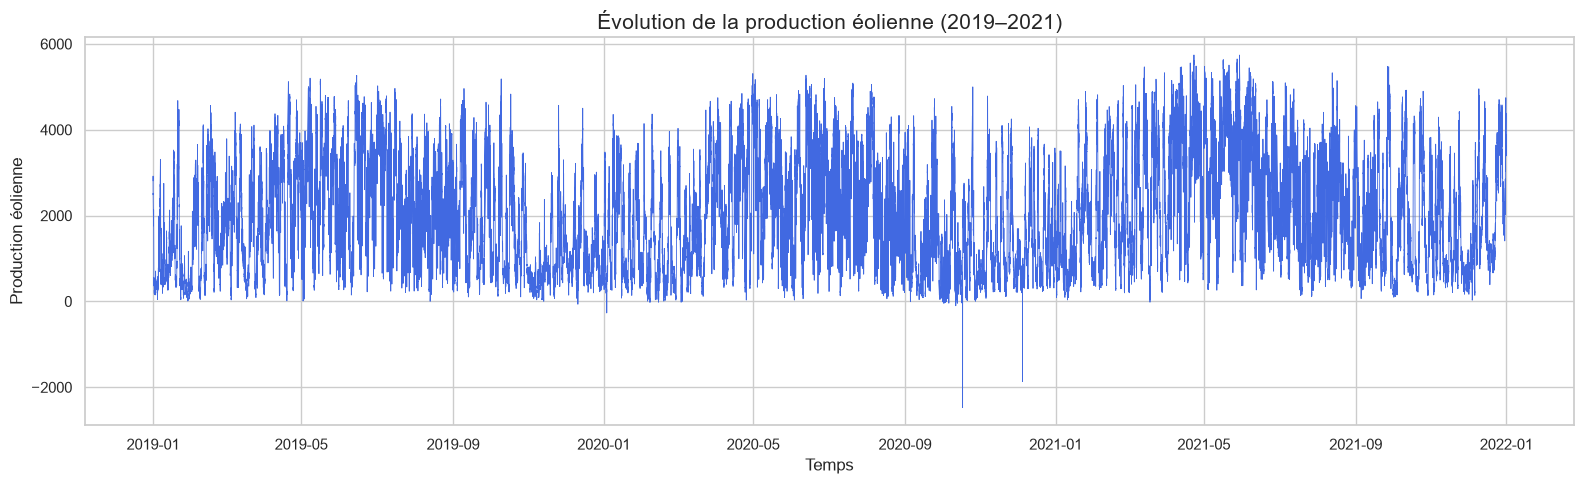

In [10]:
# 8. ÉVOLUTION DE LA PRODUCTION ÉOLIENNE

plt.figure(figsize=(16,5))

plt.plot(
    energy_df["Time"],
    energy_df["Wind_production"],
    color="royalblue",
    linewidth=0.6
)

plt.title("Évolution de la production éolienne (2019–2021)", fontsize=15)
plt.xlabel("Temps")
plt.ylabel("Production éolienne")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "wind_production_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

La production éolienne présente une forte variabilité au cours de la période d'étude.

Contrairement à la production photovoltaïque, elle ne suit pas une saisonnalité régulière mais dépend principalement des conditions de vent.

Des pics importants de production sont observés tout au long de l'année, traduisant le caractère intermittent de cette source d'énergie renouvelable.

Quelques valeurs négatives apparaissent également dans le jeu de données. Elles sont conservées à ce stade et feront l'objet d'une analyse spécifique lors des étapes ultérieures.

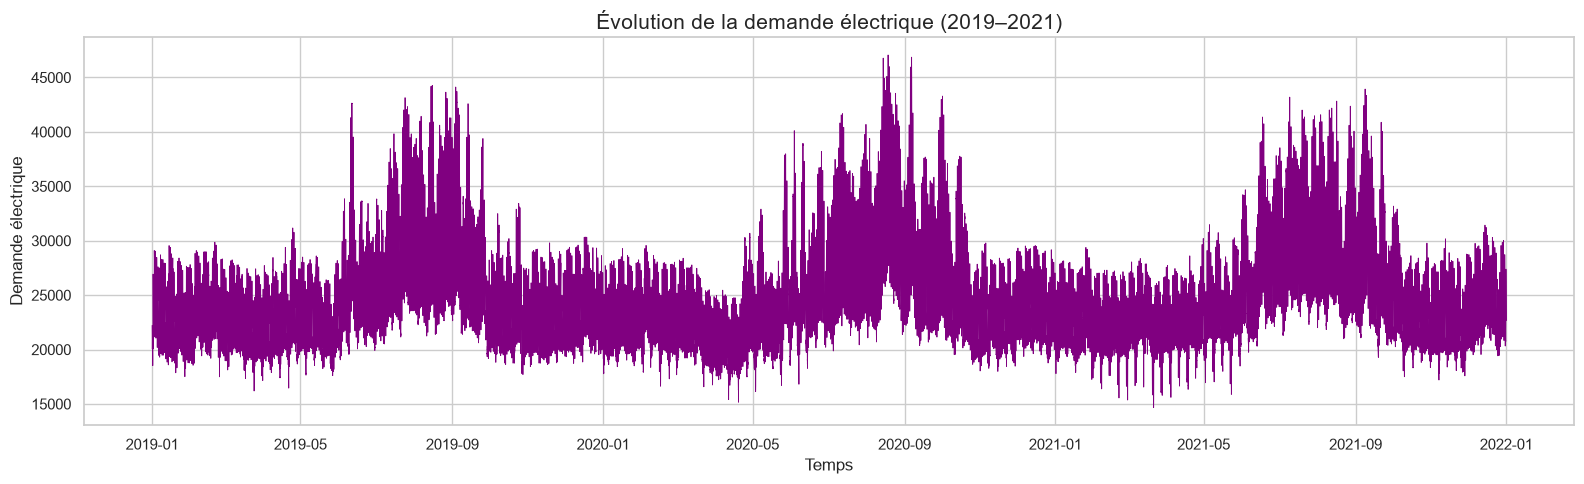

In [11]:
# 9. ÉVOLUTION DE LA DEMANDE ÉLECTRIQUE

plt.figure(figsize=(16,5))

plt.plot(
    energy_df["Time"],
    energy_df["Electric_demand"],
    color="purple",
    linewidth=0.6
)

plt.title("Évolution de la demande électrique (2019–2021)", fontsize=15)
plt.xlabel("Temps")
plt.ylabel("Demande électrique")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "electric_demand_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

La demande électrique présente une saisonnalité annuelle marquée.

Les niveaux de consommation sont plus élevés durant les périodes hivernales et plus faibles durant les mois d'été.

Cette évolution peut être expliquée par les besoins en chauffage, les habitudes de consommation ainsi que les variations climatiques.

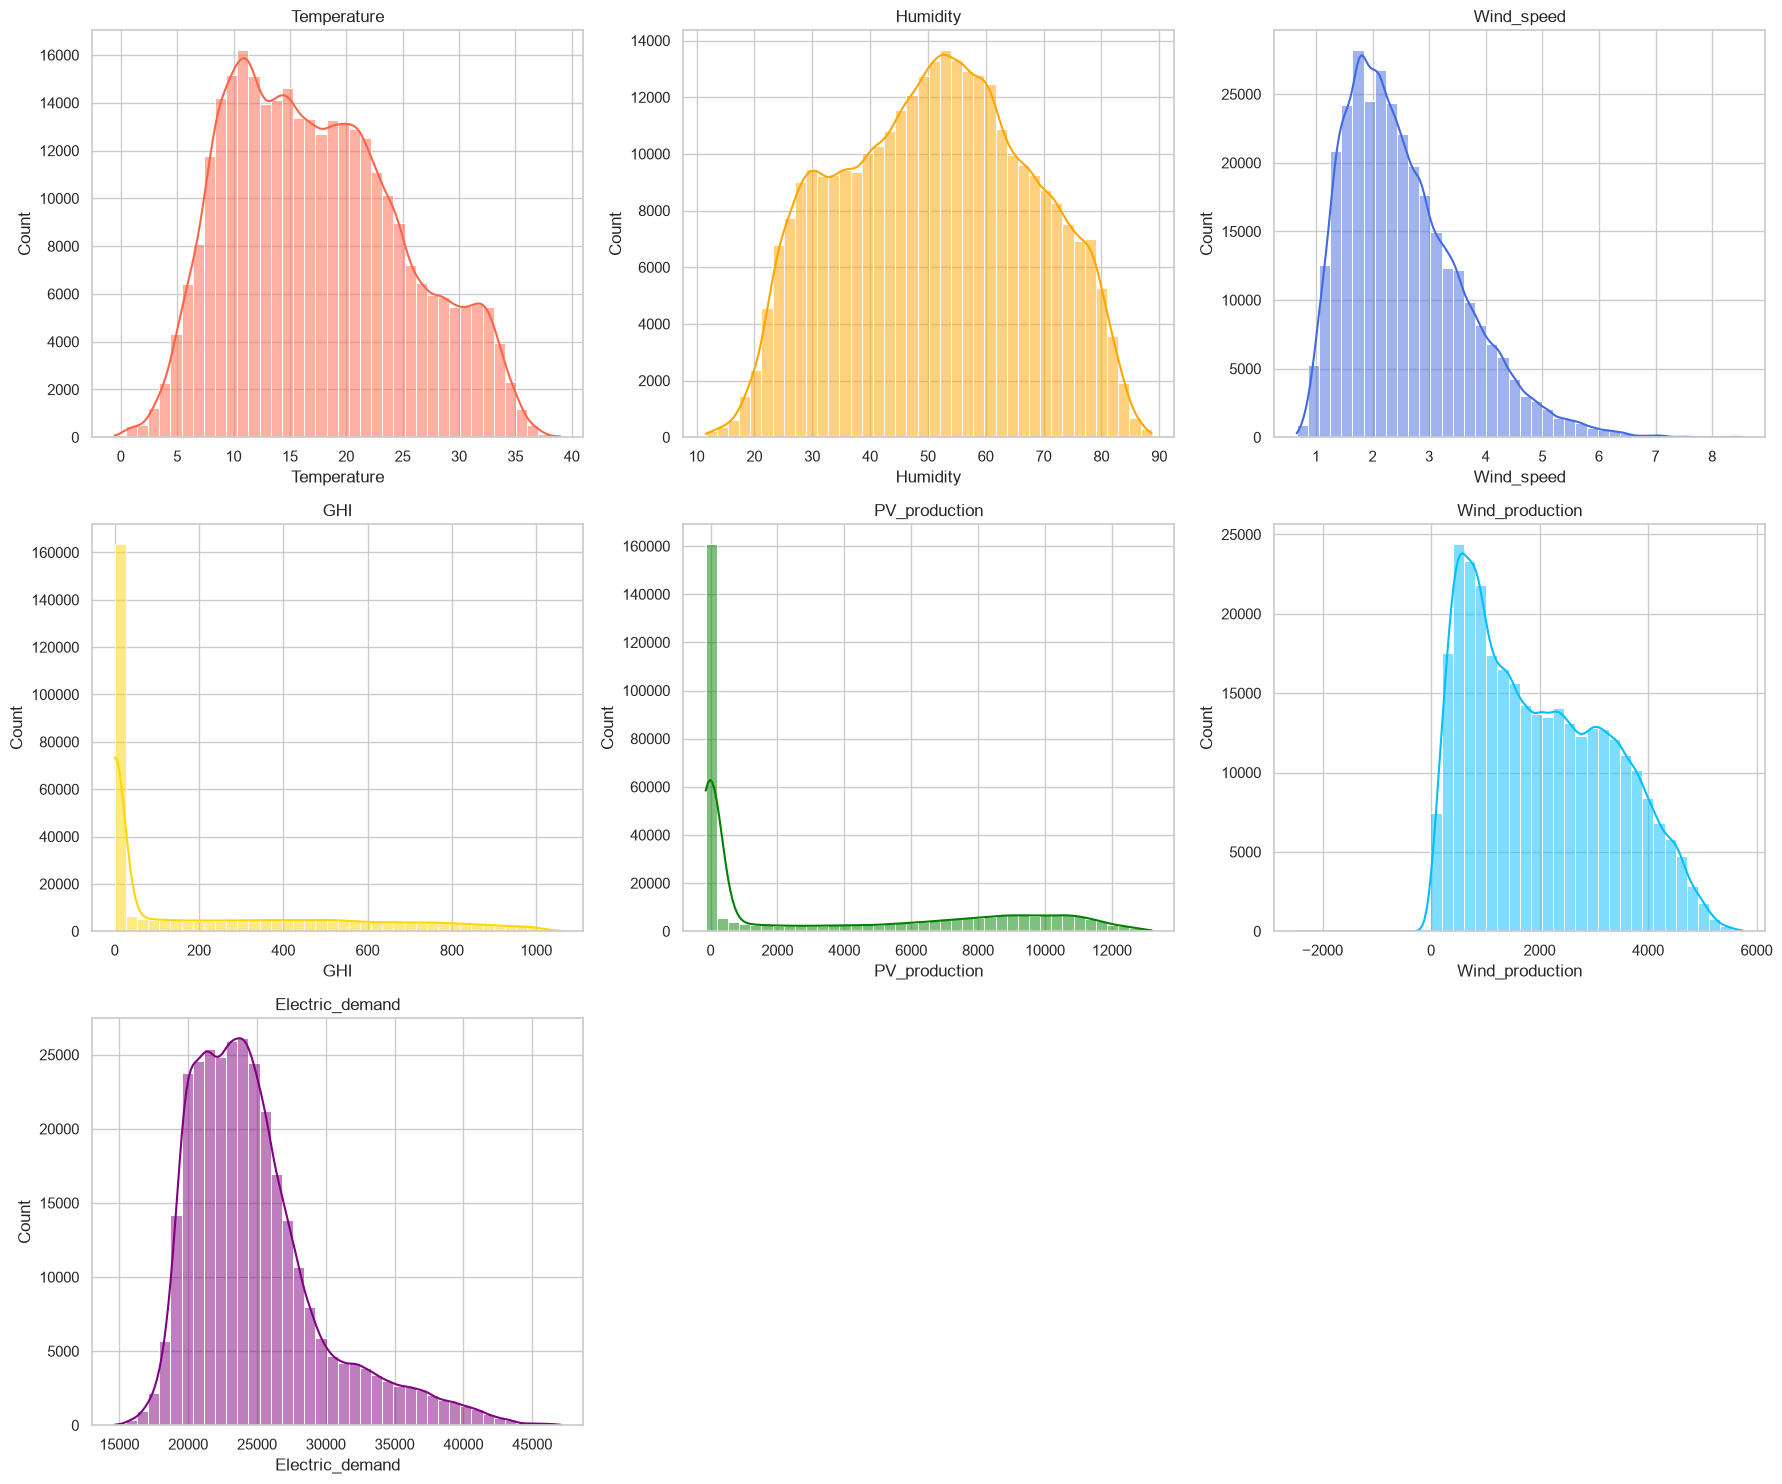

In [12]:
# 10. DISTRIBUTION DES VARIABLES PRINCIPALES

variables = [
    "Temperature",
    "Humidity",
    "Wind_speed",
    "GHI",
    "PV_production",
    "Wind_production",
    "Electric_demand"
]

fig, axes = plt.subplots(3, 3, figsize=(18,15))

axes = axes.flatten()

colors = [
    "tomato",
    "orange",
    "royalblue",
    "gold",
    "green",
    "deepskyblue",
    "purple"
]

for i, var in enumerate(variables):

    sns.histplot(
        energy_df[var],
        bins=40,
        kde=True,
        color=colors[i],
        ax=axes[i]
    )

    axes[i].set_title(var)

# Supprimer les axes inutilisés
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "variables_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

Les distributions mettent en évidence les caractéristiques propres à chaque variable.

Les variables météorologiques présentent des distributions cohérentes avec les phénomènes physiques observés.

Les variables photovoltaïques et le rayonnement solaire comportent un grand nombre de valeurs nulles, correspondant aux périodes nocturnes.

La production éolienne présente une distribution plus étalée, tandis que la demande électrique est relativement concentrée autour de sa moyenne avec quelques valeurs extrêmes.

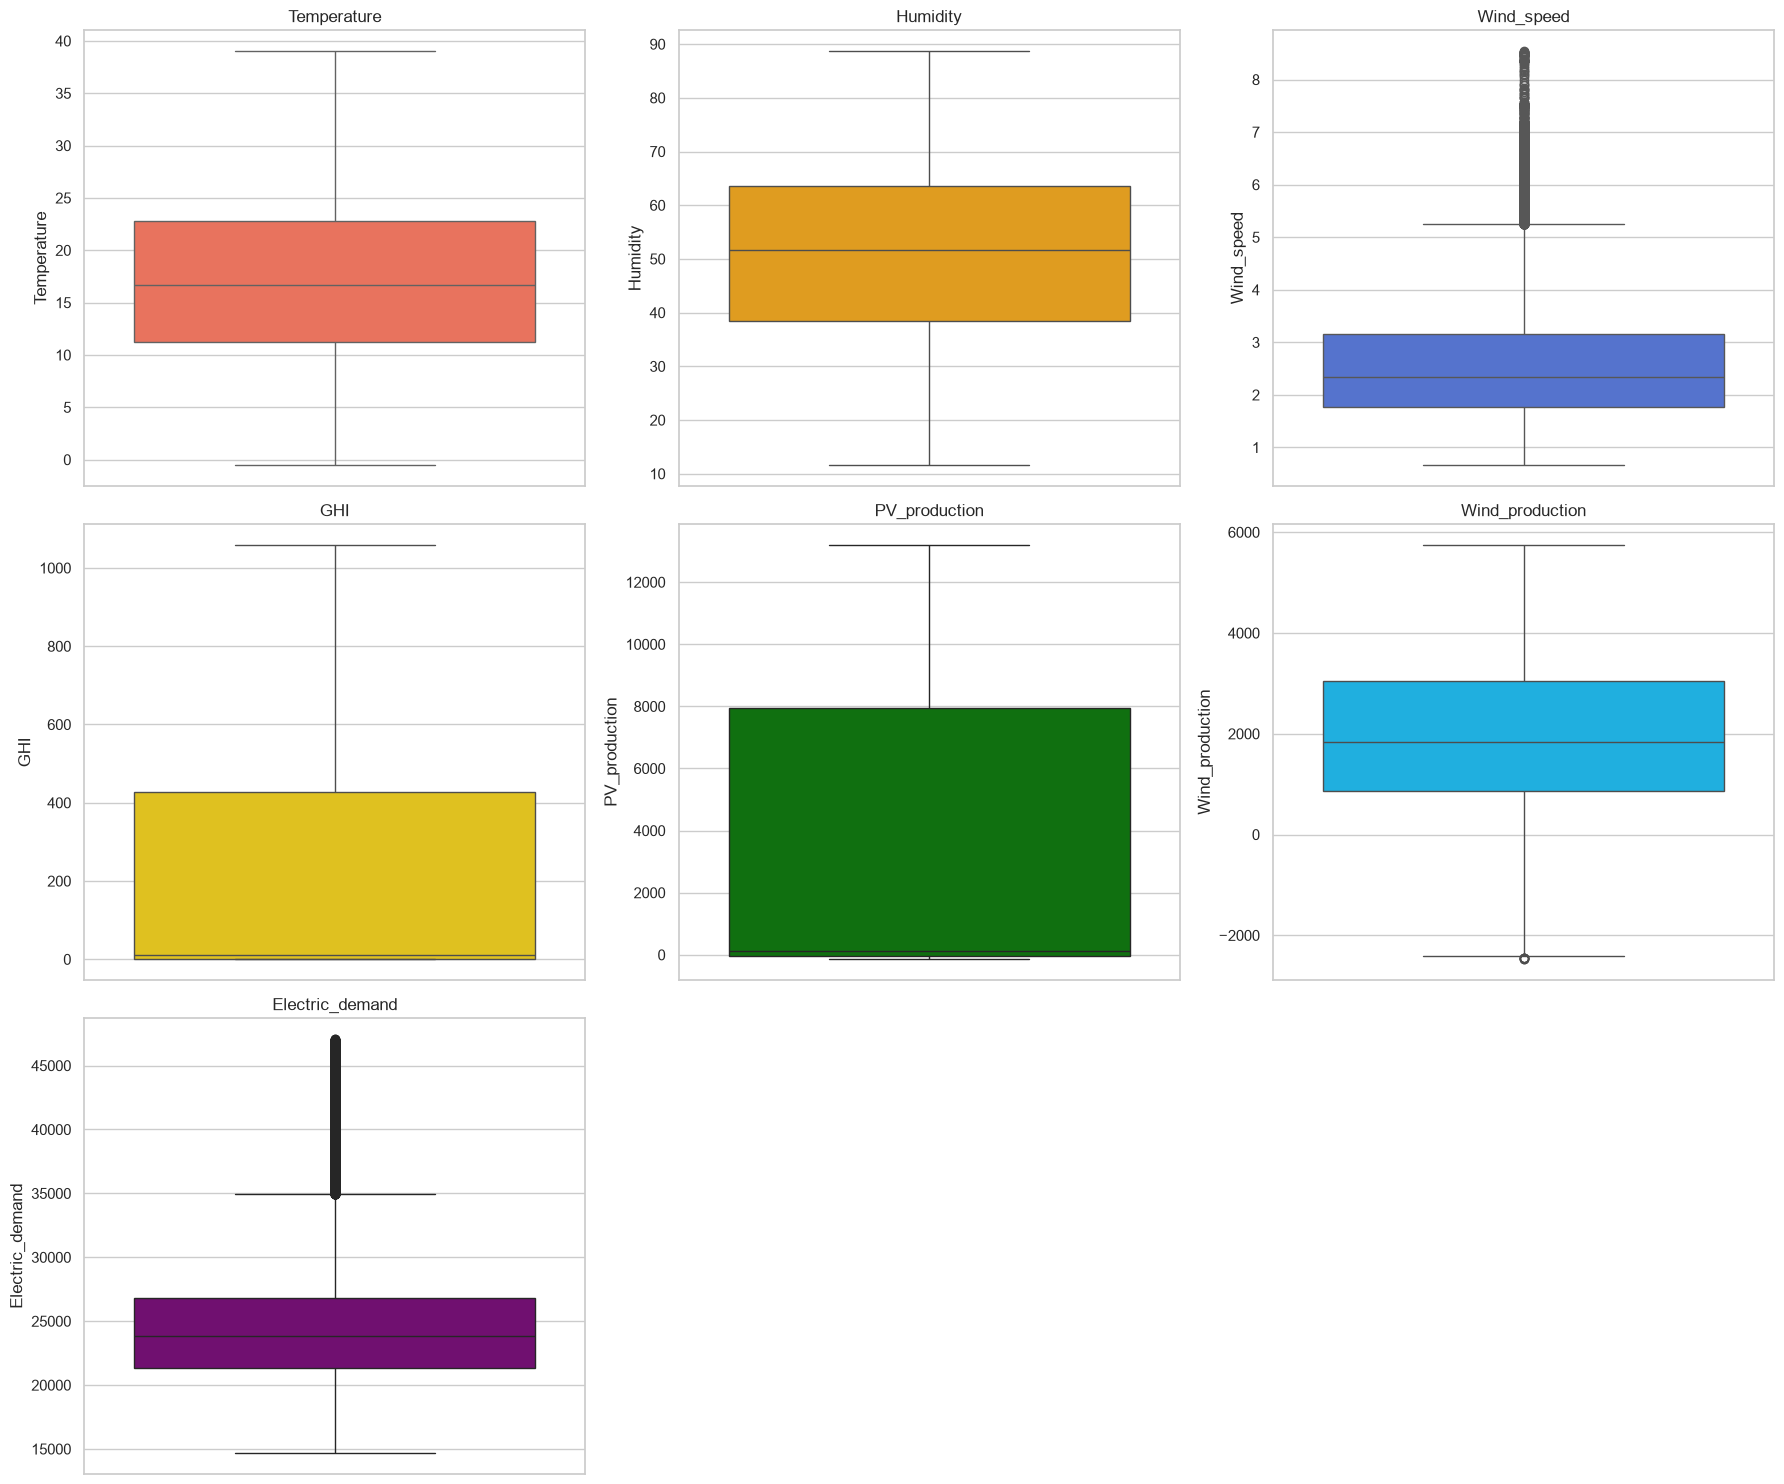

In [13]:
# 11. BOXPLOTS DES VARIABLES PRINCIPALES

variables = [
    "Temperature",
    "Humidity",
    "Wind_speed",
    "GHI",
    "PV_production",
    "Wind_production",
    "Electric_demand"
]

fig, axes = plt.subplots(3, 3, figsize=(18,15))

axes = axes.flatten()

colors = [
    "tomato",
    "orange",
    "royalblue",
    "gold",
    "green",
    "deepskyblue",
    "purple"
]

for i, var in enumerate(variables):

    sns.boxplot(
        y=energy_df[var],
        color=colors[i],
        ax=axes[i]
    )

    axes[i].set_title(var)

# Supprimer les axes inutilisés
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "variables_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

Les boxplots permettent d'identifier la présence de valeurs extrêmes dans plusieurs variables.

Ces observations atypiques concernent principalement les pics de production énergétique ou certains événements météorologiques particuliers.

Compte tenu de leur origine potentiellement physique, ces valeurs sont conservées afin de préserver la variabilité naturelle du jeu de données.

In [14]:
# 12. DÉTECTION DES VALEURS EXTRÊMES (IQR)

variables = [
    "Temperature",
    "Humidity",
    "Wind_speed",
    "GHI",
    "PV_production",
    "Wind_production",
    "Electric_demand"
]

outliers = []

for var in variables:

    Q1 = energy_df[var].quantile(0.25)
    Q3 = energy_df[var].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = (
        (energy_df[var] < lower) |
        (energy_df[var] > upper)
    ).sum()

    percentage = n_outliers / len(energy_df) * 100

    outliers.append([
        var,
        n_outliers,
        round(percentage,2)
    ])

outliers_df = pd.DataFrame(
    outliers,
    columns=[
        "Variable",
        "Nombre d'outliers",
        "Pourcentage (%)"
    ]
)

display(outliers_df)

,Variable,Nombre d'outliers,Pourcentage (%)
0,Temperature,0,0.000
1,Humidity,0,0.000
2,Wind_speed,5728,1.810
3,GHI,0,0.000
4,PV_production,0,0.000
5,Wind_production,6,0.000
6,Electric_demand,17023,5.390


### Interprétation

L'analyse quantitative des valeurs extrêmes confirme les observations réalisées à l'aide des boxplots.

Les variables énergétiques présentent naturellement davantage de valeurs atypiques que les variables météorologiques, notamment lors des pics de production ou de consommation.

Aucune suppression automatique des observations n'est réalisée à cette étape afin de ne pas altérer les phénomènes réels présents dans les données.

# 13. ANALYSE SAISONNIÈRE

In [15]:
# LIBELLÉS DES SAISONS

season_labels = {
    1: "Hiver",
    2: "Printemps",
    3: "Été",
    4: "Automne"
}

energy_df["Season_name"] = energy_df["Season"].map(season_labels)

C:\Users\celes\AppData\Local\Temp\ipykernel_1036\3816121732.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


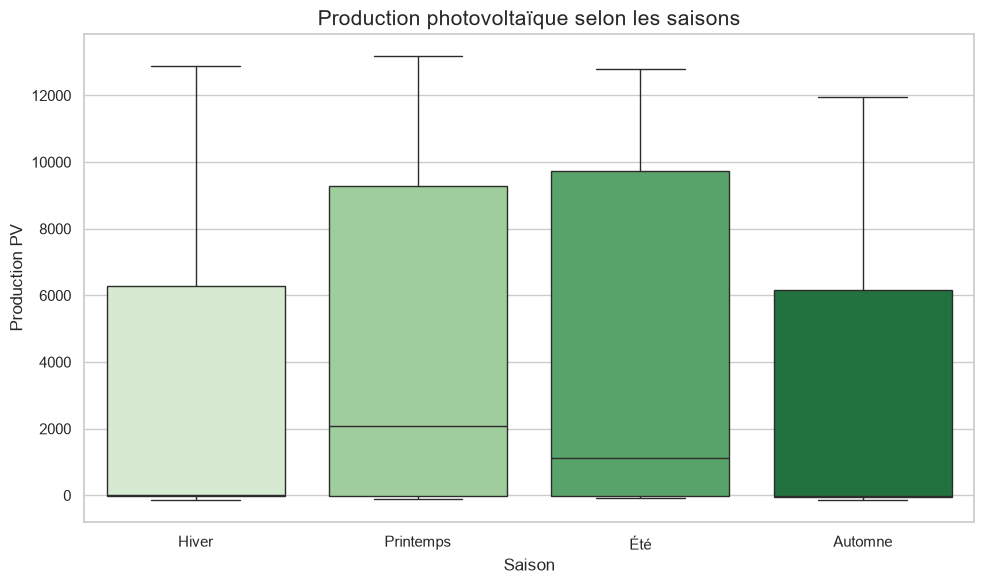

In [16]:
# 13.1 PRODUCTION PHOTOVOLTAÏQUE PAR SAISON
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=energy_df,
    x="Season_name",
    y="PV_production",
    palette="Greens"
)

plt.title("Production photovoltaïque selon les saisons", fontsize=15)
plt.xlabel("Saison")
plt.ylabel("Production PV")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pv_by_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\celes\AppData\Local\Temp\ipykernel_1036\3207167491.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


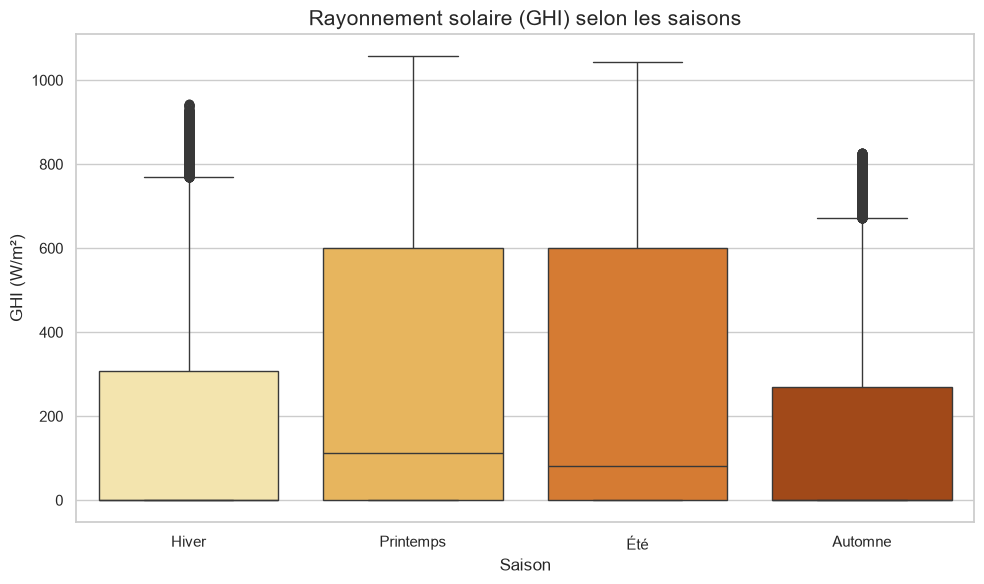

In [17]:
# 13.2 GHI PAR SAISON

plt.figure(figsize=(10,6))

sns.boxplot(
    data=energy_df,
    x="Season_name",
    y="GHI",
    palette="YlOrBr"
)

plt.title("Rayonnement solaire (GHI) selon les saisons", fontsize=15)
plt.xlabel("Saison")
plt.ylabel("GHI (W/m²)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ghi_by_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\celes\AppData\Local\Temp\ipykernel_1036\9239777.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


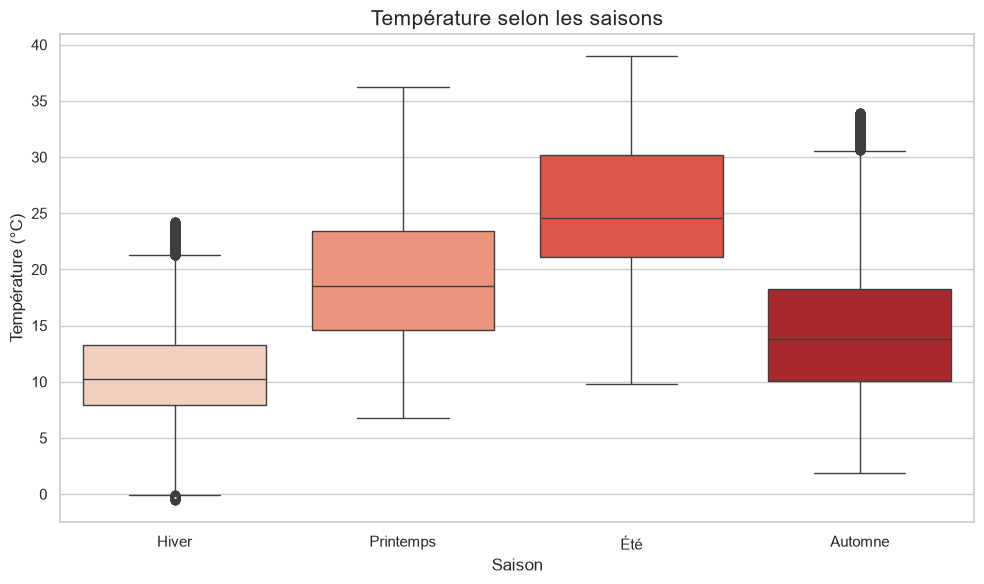

In [18]:
# 13.3 TEMPÉRATURE PAR SAISON
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=energy_df,
    x="Season_name",
    y="Temperature",
    palette="Reds"
)

plt.title("Température selon les saisons", fontsize=15)
plt.xlabel("Saison")
plt.ylabel("Température (°C)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "temperature_by_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\celes\AppData\Local\Temp\ipykernel_1036\2891899179.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


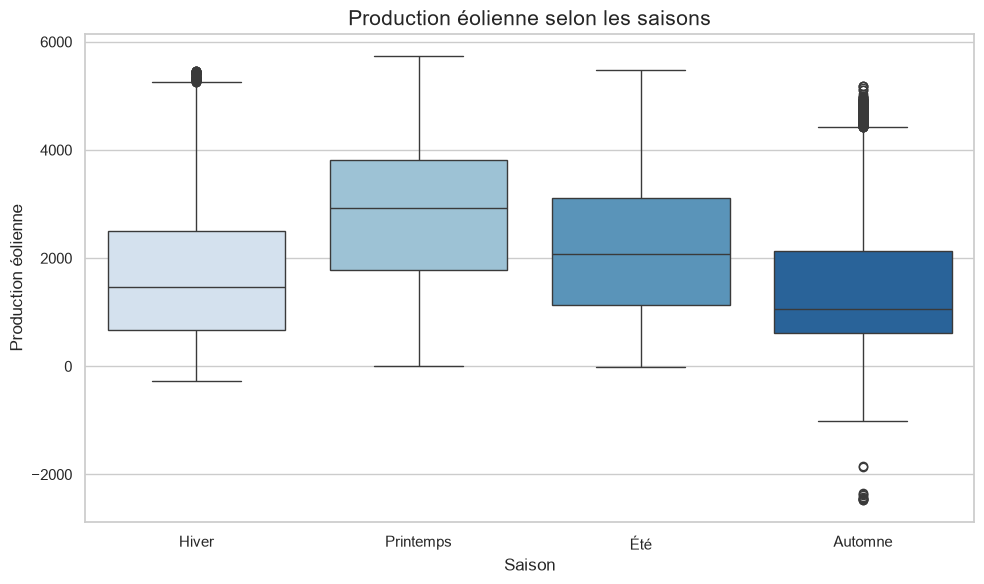

In [19]:
# 13.4 PRODUCTION ÉOLIENNE PAR SAISON

plt.figure(figsize=(10,6))

sns.boxplot(
    data=energy_df,
    x="Season_name",
    y="Wind_production",
    palette="Blues"
)

plt.title("Production éolienne selon les saisons", fontsize=15)
plt.xlabel("Saison")
plt.ylabel("Production éolienne")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "wind_by_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\celes\AppData\Local\Temp\ipykernel_1036\2017580643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


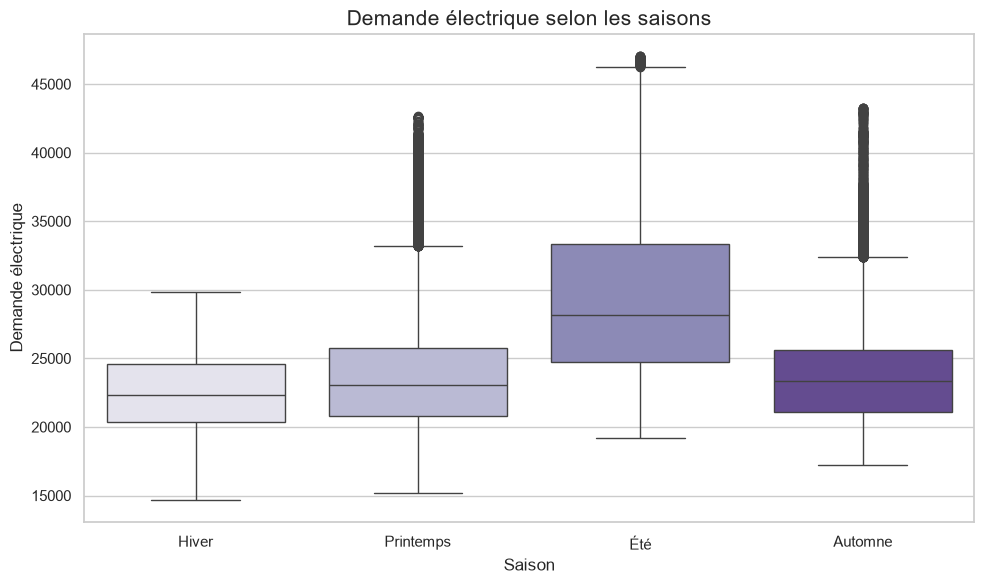

In [20]:
# 13.5 DEMANDE ÉLECTRIQUE PAR SAISON

plt.figure(figsize=(10,6))

sns.boxplot(
    data=energy_df,
    x="Season_name",
    y="Electric_demand",
    palette="Purples"
)

plt.title("Demande électrique selon les saisons", fontsize=15)
plt.xlabel("Saison")
plt.ylabel("Demande électrique")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "demand_by_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

Les analyses saisonnières montrent une forte influence des conditions climatiques sur les variables énergétiques.

La production photovoltaïque est maximale durant l'été, en raison d'un rayonnement solaire plus important.

La température suit une évolution similaire, tandis que la demande électrique augmente principalement en hiver.

La production éolienne présente une variabilité plus importante et ne suit pas une saisonnalité aussi marquée que le photovoltaïque.

# 14. ANALYSE MENSUELLE

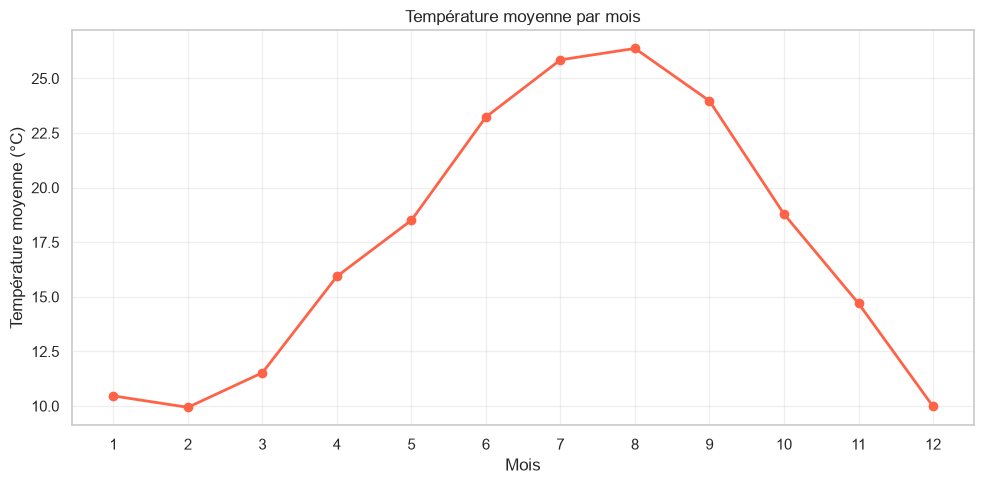

In [21]:
# 14.1 TEMPÉRATURE MOYENNE PAR MOIS

monthly_temp = energy_df.groupby("Month")["Temperature"].mean()

plt.figure(figsize=(10,5))

monthly_temp.plot(
    marker="o",
    color="tomato",
    linewidth=2
)

plt.title("Température moyenne par mois")
plt.xlabel("Mois")
plt.ylabel("Température moyenne (°C)")
plt.xticks(range(1,13))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

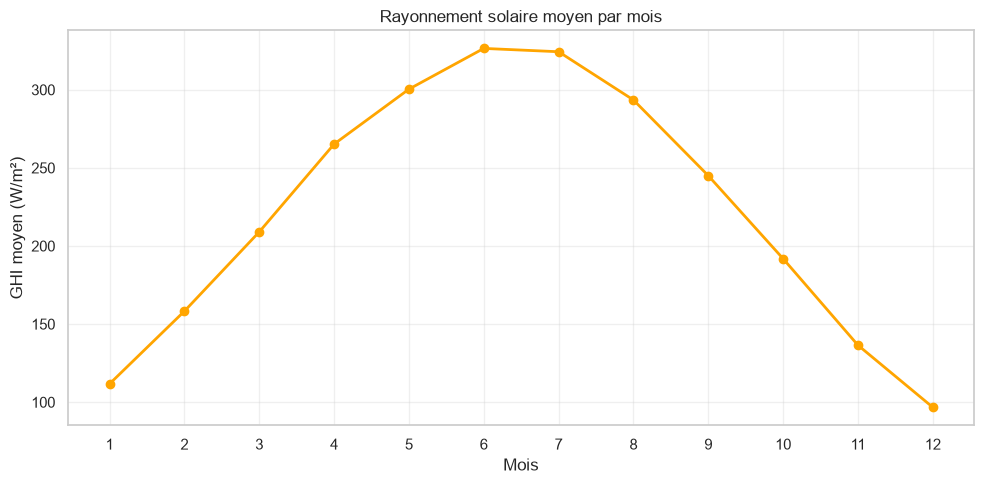

In [22]:
# 14.2 GHI MOYEN PAR MOIS

monthly_ghi = energy_df.groupby("Month")["GHI"].mean()

plt.figure(figsize=(10,5))

monthly_ghi.plot(
    marker="o",
    color="orange",
    linewidth=2
)

plt.title("Rayonnement solaire moyen par mois")
plt.xlabel("Mois")
plt.ylabel("GHI moyen (W/m²)")
plt.xticks(range(1,13))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_ghi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

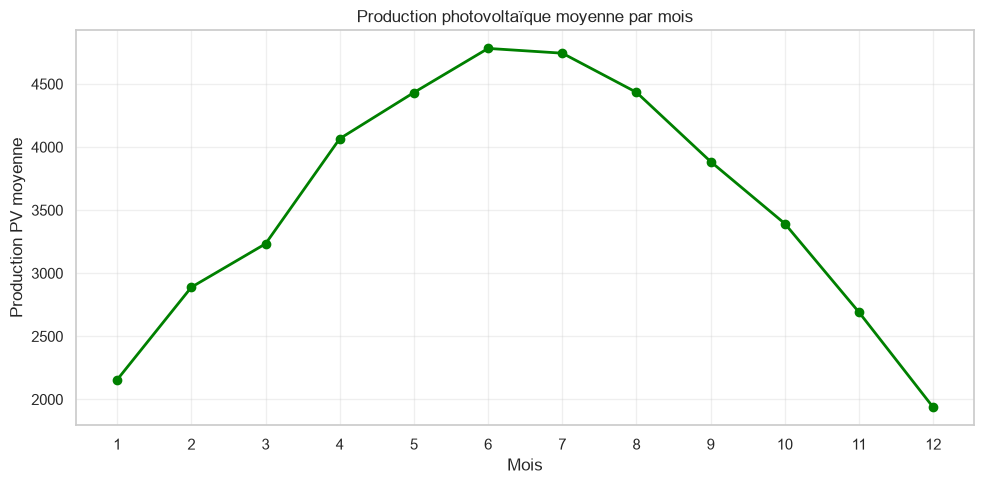

In [23]:
# 14.3 PV PAR MOIS

monthly_pv = energy_df.groupby("Month")["PV_production"].mean()

plt.figure(figsize=(10,5))

monthly_pv.plot(
    marker="o",
    color="green",
    linewidth=2
)

plt.title("Production photovoltaïque moyenne par mois")
plt.xlabel("Mois")
plt.ylabel("Production PV moyenne")

plt.xticks(range(1,13))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_pv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

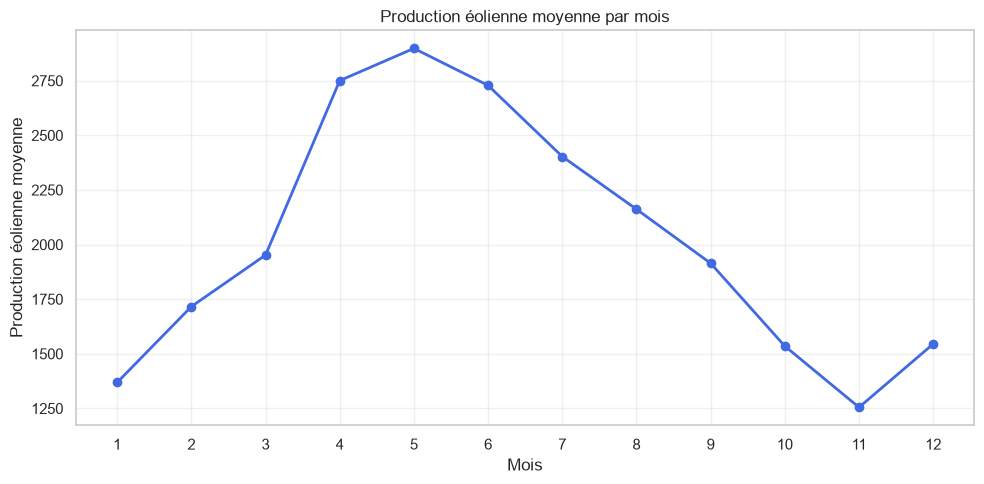

In [24]:
# 14.4 ÉOLIEN PAR MOIS

monthly_wind = energy_df.groupby("Month")["Wind_production"].mean()

plt.figure(figsize=(10,5))

monthly_wind.plot(
    marker="o",
    color="royalblue",
    linewidth=2
)

plt.title("Production éolienne moyenne par mois")
plt.xlabel("Mois")
plt.ylabel("Production éolienne moyenne")

plt.xticks(range(1,13))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_wind.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

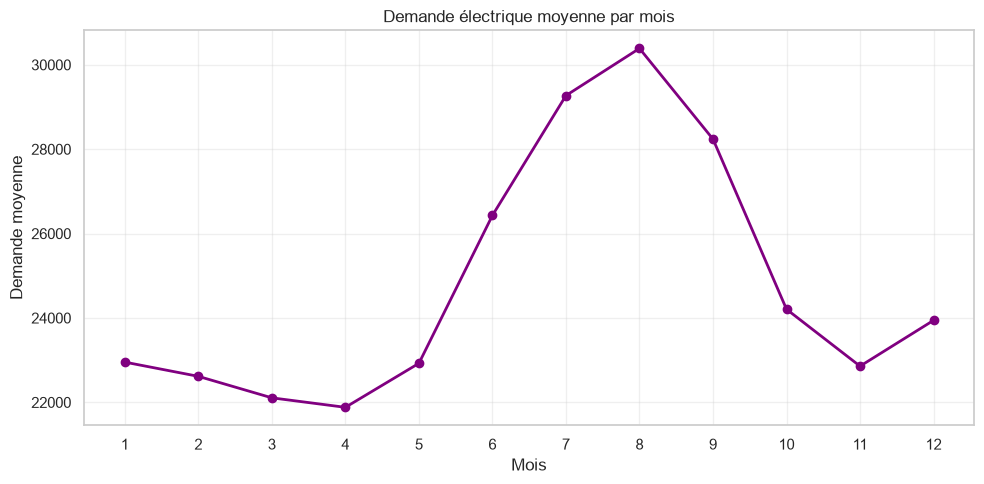

In [25]:
# 14.5 DEMANDE PAR MOIS

monthly_demand = energy_df.groupby("Month")["Electric_demand"].mean()

plt.figure(figsize=(10,5))

monthly_demand.plot(
    marker="o",
    color="purple",
    linewidth=2
)

plt.title("Demande électrique moyenne par mois")
plt.xlabel("Mois")
plt.ylabel("Demande moyenne")

plt.xticks(range(1,13))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

Les moyennes mensuelles mettent clairement en évidence les cycles saisonniers.

Les mois estivaux présentent les températures, le rayonnement solaire et la production photovoltaïque les plus élevés.

À l'inverse, la demande électrique est plus importante durant les mois d'hiver, traduisant une influence directe des conditions climatiques sur la consommation énergétique.

# 15. ANALYSE HEBDOMADAIRE

### Avant les graphiques, créons des noms de jours lisibles.

In [26]:
# NOMS DES JOURS

days = {
    0:"Lundi",
    1:"Mardi",
    2:"Mercredi",
    3:"Jeudi",
    4:"Vendredi",
    5:"Samedi",
    6:"Dimanche"
}

energy_df["Weekday_name"] = energy_df["Weekday"].map(days)

C:\Users\celes\AppData\Local\Temp\ipykernel_1036\1426038071.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


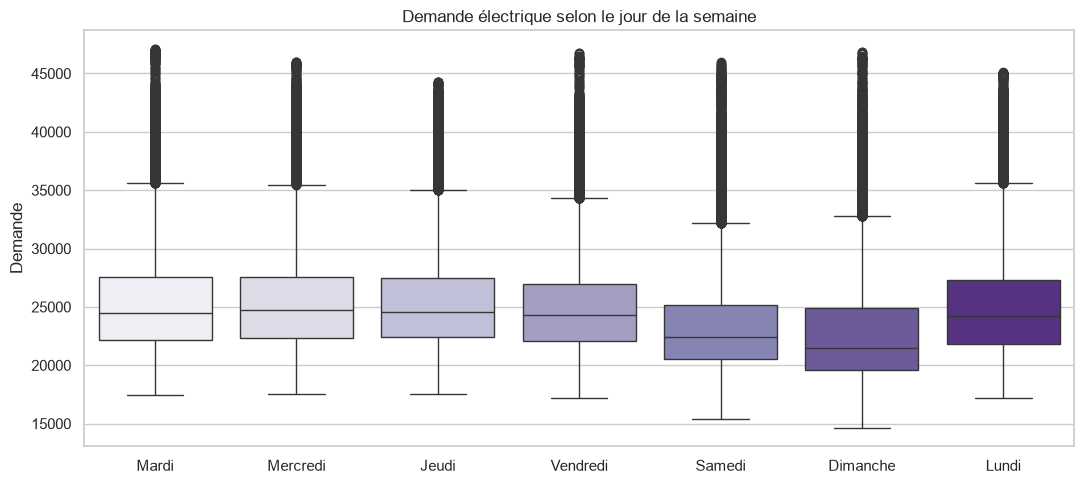

In [27]:
# DEMANDE SELON LE JOUR

plt.figure(figsize=(11,5))

sns.boxplot(
    data=energy_df,
    x="Weekday_name",
    y="Electric_demand",
    palette="Purples"
)

plt.title("Demande électrique selon le jour de la semaine")
plt.xlabel("")
plt.ylabel("Demande")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "weekday_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\celes\AppData\Local\Temp\ipykernel_1036\907330067.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


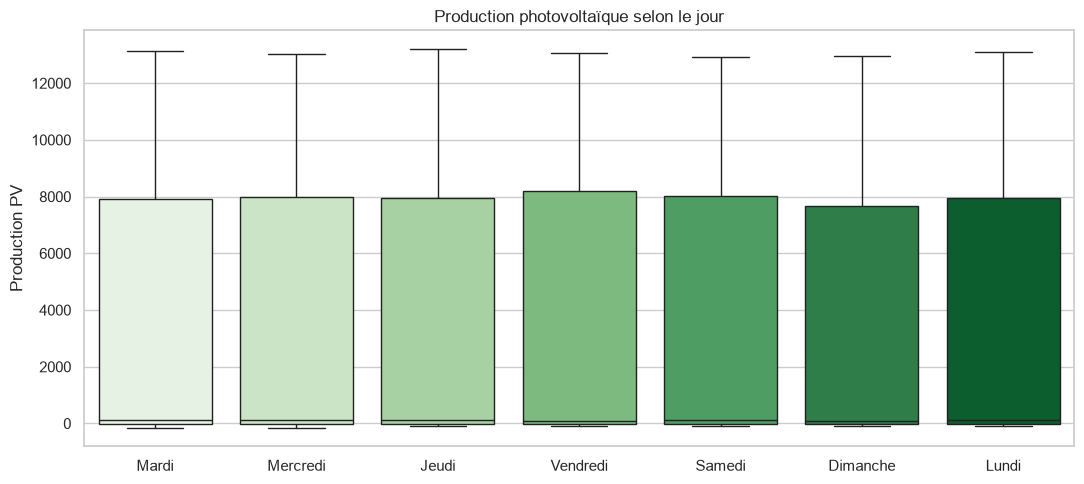

In [28]:
# PV SELON LE JOUR

plt.figure(figsize=(11,5))

sns.boxplot(
    data=energy_df,
    x="Weekday_name",
    y="PV_production",
    palette="Greens"
)

plt.title("Production photovoltaïque selon le jour")
plt.xlabel("")
plt.ylabel("Production PV")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "weekday_pv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

Les distributions hebdomadaires montrent que la production photovoltaïque reste relativement stable selon le jour de la semaine.

En revanche, la demande électrique présente de légères différences entre les jours ouvrables et le week-end, reflétant les habitudes de consommation des usagers.

# 16. Analyse horaire des variables

Cette section étudie l'évolution moyenne des principales variables au cours
des vingt-quatre heures d'une journée.

L'objectif est d'identifier les profils journaliers caractéristiques des
variables climatiques et énergétiques afin de mieux comprendre les périodes
de forte production et de forte consommation.

Ces informations seront particulièrement utiles pour la création de nouvelles
variables lors de l'étape de Feature Engineering.

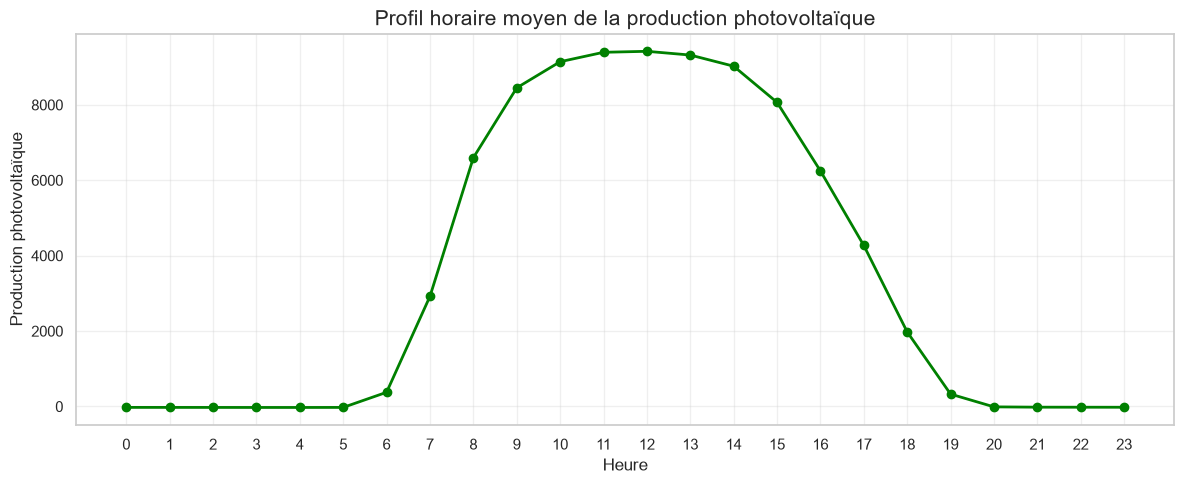

In [29]:
# 16.1 PROFIL HORAIRE DE LA PRODUCTION PHOTOVOLTAÏQUE


hourly_pv = energy_df.groupby("Hour")["PV_production"].mean()

plt.figure(figsize=(12,5))

hourly_pv.plot(
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Profil horaire moyen de la production photovoltaïque", fontsize=15)
plt.xlabel("Heure")
plt.ylabel("Production photovoltaïque")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "hourly_pv_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

La production photovoltaïque est nulle durant la nuit.

Elle augmente progressivement après le lever du soleil, atteint son maximum
autour de midi, puis diminue jusqu'au coucher du soleil.

Ce comportement correspond au cycle naturel du rayonnement solaire et confirme
la forte dépendance de cette source d'énergie aux conditions climatiques.

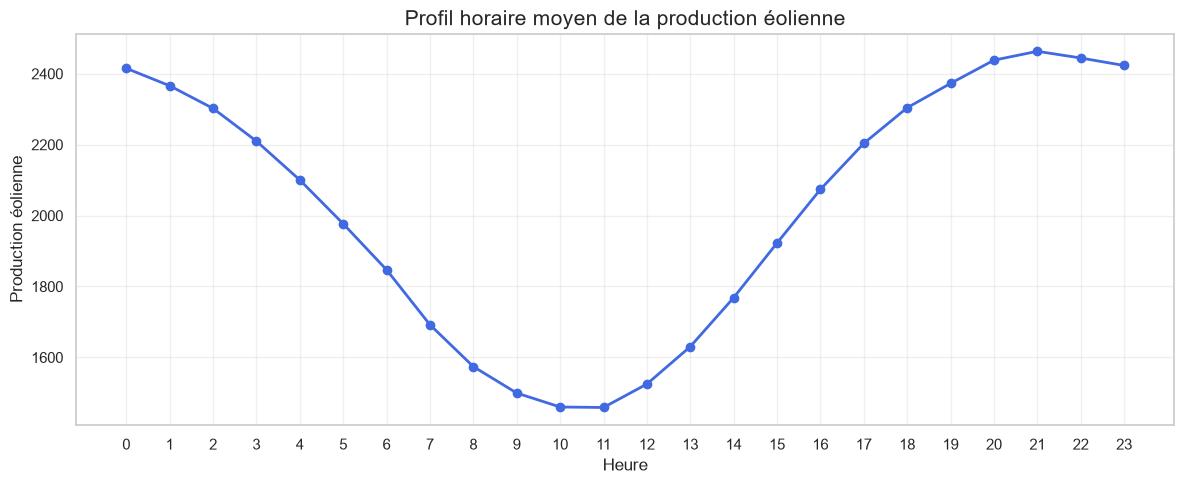

In [30]:
# 16.2 PROFIL HORAIRE DE LA PRODUCTION ÉOLIENNE

hourly_wind = energy_df.groupby("Hour")["Wind_production"].mean()

plt.figure(figsize=(12,5))

hourly_wind.plot(
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.title("Profil horaire moyen de la production éolienne", fontsize=15)
plt.xlabel("Heure")
plt.ylabel("Production éolienne")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "hourly_wind_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

Contrairement à la production photovoltaïque, la production éolienne reste
présente durant toute la journée.

Les variations horaires sont moins marquées, ce qui traduit le caractère plus
irrégulier du vent.

Cette source d'énergie constitue ainsi un complément intéressant à la
production solaire.

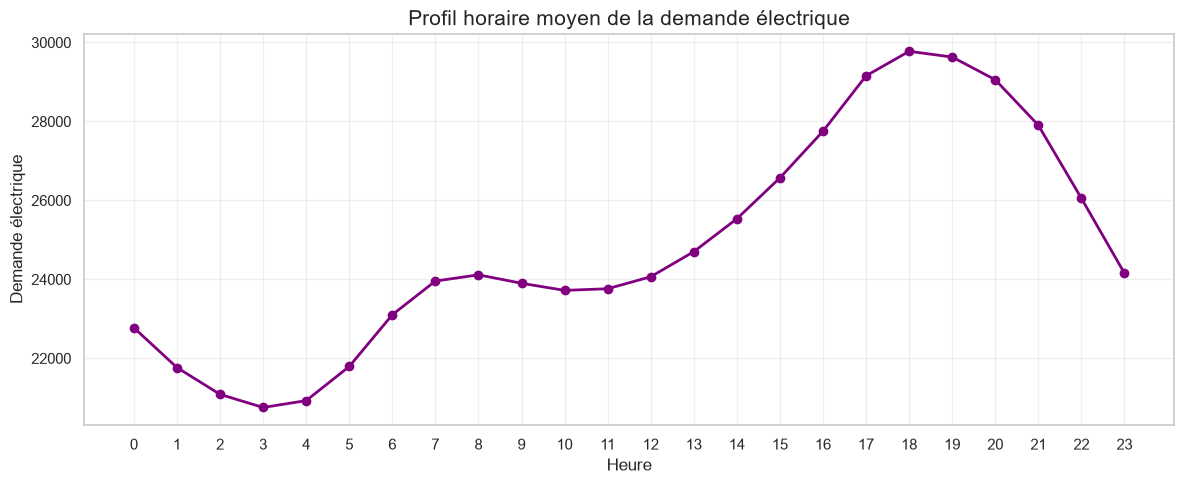

In [31]:
# 16.3 PROFIL HORAIRE DE LA DEMANDE ÉLECTRIQUE

hourly_demand = energy_df.groupby("Hour")["Electric_demand"].mean()

plt.figure(figsize=(12,5))

hourly_demand.plot(
    marker="o",
    linewidth=2,
    color="purple"
)

plt.title("Profil horaire moyen de la demande électrique", fontsize=15)
plt.xlabel("Heure")
plt.ylabel("Demande électrique")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "hourly_demand_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

La demande électrique varie fortement au cours de la journée.

Les niveaux de consommation augmentent progressivement durant la matinée,
atteignent un maximum durant les périodes d'activité, puis diminuent en
soirée.

Cette évolution reflète les habitudes quotidiennes de consommation des
usagers.

# 17. Cartes thermiques (Heatmaps)

Les heatmaps permettent de représenter simultanément les variations
journalières et horaires des variables énergétiques.

Elles offrent une vision synthétique des périodes de forte production
ou de forte consommation.

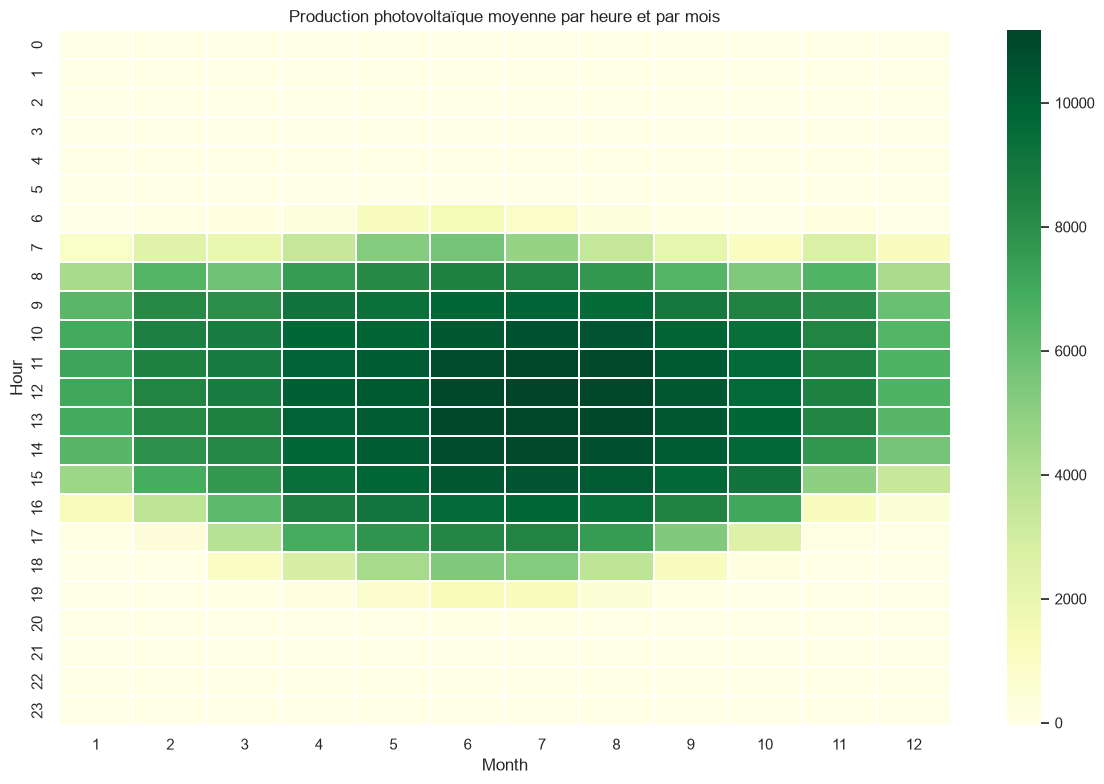

In [32]:
# 17.1 Heatmap de la production photovoltaïque

pv_heatmap = energy_df.pivot_table(
    values="PV_production",
    index="Hour",
    columns="Month",
    aggfunc="mean"
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pv_heatmap,
    cmap="YlGn",
    linewidths=0.2
)

plt.title("Production photovoltaïque moyenne par heure et par mois")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "heatmap_pv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

La production photovoltaïque est concentrée entre les heures d'ensoleillement.

Les niveaux les plus élevés sont observés durant les mois d'été, tandis que
la production est très faible pendant les mois d'hiver.

Cette représentation met clairement en évidence la double saisonnalité
journalière et annuelle de la production solaire.

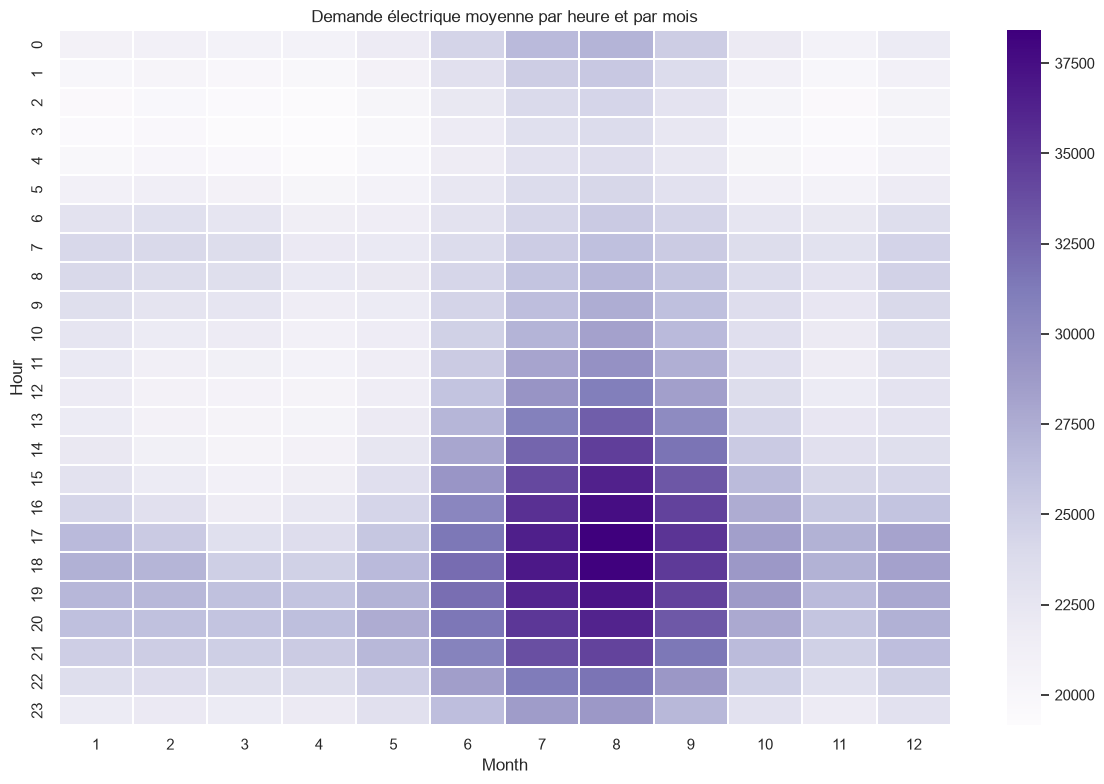

In [33]:
# 16.2 Heatmap de la demande électrique

demand_heatmap = energy_df.pivot_table(
    values="Electric_demand",
    index="Hour",
    columns="Month",
    aggfunc="mean"
)

plt.figure(figsize=(12,8))

sns.heatmap(
    demand_heatmap,
    cmap="Purples",
    linewidths=0.2
)

plt.title("Demande électrique moyenne par heure et par mois")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "heatmap_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interprétation

La demande électrique varie à la fois selon les heures de la journée et selon
les mois de l'année.

Les périodes de forte consommation apparaissent principalement durant les mois
les plus froids, avec des profils horaires correspondant aux périodes
d'activité quotidienne.

# 18. Analyse des corrélations

L'analyse des corrélations permet de mesurer la force des relations
linéaires entre les variables climatiques et énergétiques.

Cette étape est essentielle avant la phase de modélisation, car elle
permet :

- d'identifier les variables les plus influentes ;
- de détecter d'éventuelles redondances entre les variables ;
- de mieux comprendre les facteurs expliquant la production énergétique.

La matrice de corrélation présentée ci-dessous est calculée à l'aide
du coefficient de Pearson.

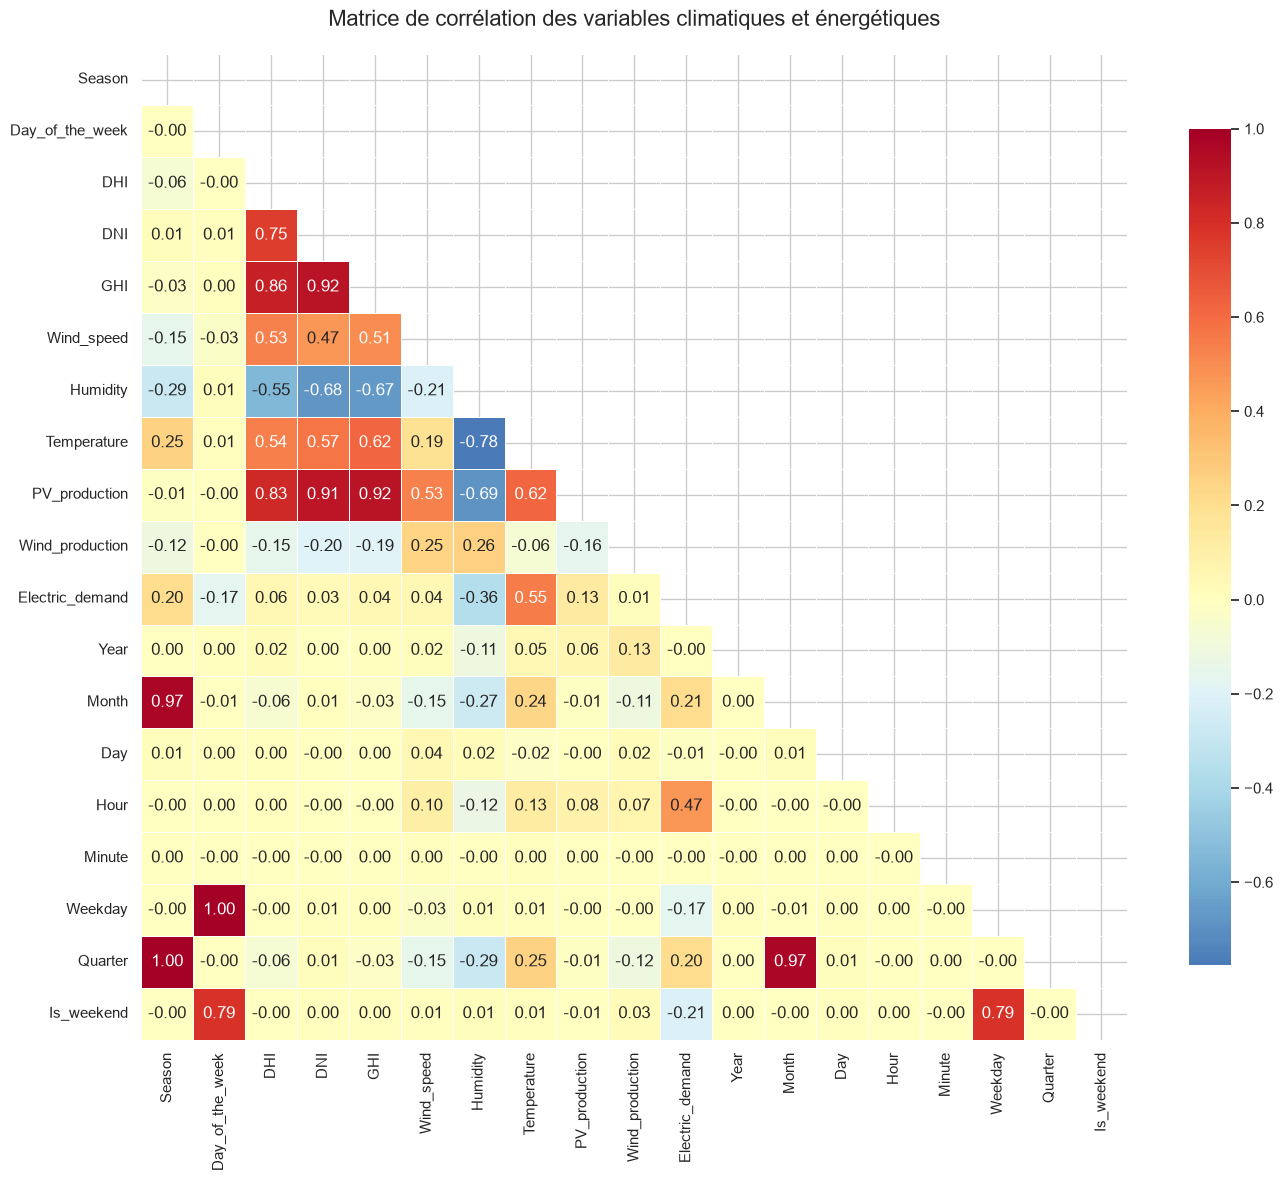

In [34]:
# 18. MATRICE DE CORRÉLATION

import numpy as np

correlation = energy_df.select_dtypes(include="number").corr()

mask = np.triu(
    np.ones_like(correlation, dtype=bool)
)

plt.figure(figsize=(14,12))

sns.heatmap(
    correlation,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title(
    "Matrice de corrélation des variables climatiques et énergétiques",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
correlation["PV_production"].sort_values(ascending=False)

PV_production      1.000
GHI                0.915
DNI                0.905
DHI                0.832
Temperature        0.625
Wind_speed         0.531
Electric_demand    0.127
Hour               0.082
Year               0.060
Minute             0.000
Weekday           -0.002
Day_of_the_week   -0.002
Day               -0.003
Is_weekend        -0.005
Quarter           -0.009
Season            -0.009
Month             -0.012
Wind_production   -0.161
Humidity          -0.691
Name: PV_production, dtype: float64

In [36]:
correlation["Wind_production"].sort_values(ascending=False)

Wind_production    1.000
Humidity           0.262
Wind_speed         0.246
Year               0.129
Hour               0.067
Is_weekend         0.027
Day                0.022
Electric_demand    0.011
Minute            -0.000
Day_of_the_week   -0.003
Weekday           -0.003
Temperature       -0.062
Month             -0.111
Quarter           -0.116
Season            -0.116
DHI               -0.150
PV_production     -0.161
GHI               -0.188
DNI               -0.199
Name: Wind_production, dtype: float64

In [37]:
correlation["Electric_demand"].sort_values(ascending=False)

Electric_demand    1.000
Temperature        0.551
Hour               0.468
Month              0.209
Quarter            0.204
Season             0.204
PV_production      0.127
DHI                0.057
GHI                0.043
Wind_speed         0.040
DNI                0.034
Wind_production    0.011
Minute            -0.000
Year              -0.002
Day               -0.011
Day_of_the_week   -0.168
Weekday           -0.168
Is_weekend        -0.208
Humidity          -0.365
Name: Electric_demand, dtype: float64

### Interprétation de la matrice de corrélation

La matrice de corrélation met en évidence les relations linéaires entre les
variables climatiques, temporelles et énergétiques du jeu de données.

#### Production photovoltaïque

La production photovoltaïque présente une très forte corrélation positive avec
les variables caractérisant le rayonnement solaire. Le coefficient de
corrélation atteint **0,915** avec le rayonnement global (GHI), **0,905** avec
le rayonnement direct (DNI) et **0,832** avec le rayonnement diffus (DHI). Ces
résultats confirment que l'énergie solaire reçue constitue le principal facteur
déterminant de la production photovoltaïque.

La température est également positivement corrélée à la production
photovoltaïque (**r = 0,625**), tandis que l'humidité présente une corrélation
négative importante (**r = -0,691**). Cette relation est cohérente puisque les
journées les plus ensoleillées sont généralement caractérisées par une faible
humidité.

#### Production éolienne

La production éolienne présente une corrélation positive avec la vitesse du vent
(**r = 0,246**), ce qui confirme l'influence directe de cette variable sur la
génération électrique éolienne. En revanche, les corrélations avec les variables
liées au rayonnement solaire restent faibles et négatives, traduisant
l'indépendance relative entre les ressources solaire et éolienne.

L'humidité présente une faible corrélation positive (**r = 0,262**), tandis que
la température n'exerce pratiquement aucune influence linéaire sur la production
éolienne (**r = -0,062**).

#### Demande électrique

La demande électrique est principalement corrélée à la température
(**r = 0,551**) ainsi qu'à l'heure de la journée (**r = 0,468**). Ces résultats
montrent que la consommation d'électricité varie fortement selon les conditions
climatiques et les habitudes de consommation au cours d'une journée.

La demande électrique présente uniquement de faibles corrélations avec les
variables de production renouvelable, ce qui suggère que la consommation dépend
davantage des comportements des utilisateurs que des conditions de production.


#### Conclusion générale de l'analyse exploratoire

L'analyse exploratoire des données a permis de mieux comprendre la structure du
jeu de données ainsi que les relations entre les variables climatiques,
temporelles et énergétiques.

Les analyses temporelles mettent en évidence une forte saisonnalité des
productions photovoltaïque et éolienne ainsi que de la demande électrique.
L'évolution des variables climatiques suit les cycles journaliers et saisonniers
attendus, confirmant la cohérence physique du jeu de données.

L'étude des distributions montre que certaines variables, notamment le
rayonnement solaire et la production photovoltaïque, présentent une forte
asymétrie liée à l'alternance entre les périodes diurnes et nocturnes. La
production éolienne, quant à elle, présente une variabilité plus importante,
reflétant le caractère aléatoire de la ressource éolienne.

L'analyse des corrélations confirme que la production photovoltaïque dépend
principalement du rayonnement solaire (GHI, DNI et DHI), tandis que la demande
électrique est davantage influencée par la température et les facteurs
temporels. La production éolienne présente une dépendance plus modérée à la
vitesse du vent, traduisant la complexité du phénomène de conversion
énergétique.

Dans l'ensemble, les données apparaissent cohérentes, complètes et adaptées aux
objectifs du projet. Cette analyse exploratoire constitue une base solide pour
les étapes suivantes de préparation des variables, de sélection des
caractéristiques pertinentes et de développement des modèles de prédiction des
productions énergétiques et de la demande électrique.